In [2]:
from tmu.models.classification.vanilla_classifier import TMClassifier
import numpy as np
import os 
import logging
import config
import pickle
from utils.optuna import save_optuna_best_results, load_optuna_best_results, run_tm_optuna_search
from utils.dataset import load_dataset
from utils.plots import plot_tm_roc_curve, plot_confusion_matrix_from_scores, plot_clause_length_distribution
from utils.booleanization import perform_color_thermometers_booleanization
from utils.training import train_tm_and_save_scores
from utils.clause_visualization import visualize_average_heatmap, visualize_per_channel_heatmaps, number_of_literals_in_clause, get_correct_sample_index, visualize_aggregated_heatmap, visualize_per_channel_level_heatmaps, build_save_path, load_raw_maps_and_plot_heatmap

/home/coder/masters_thesis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-04-10 21:08:00,484 - matplotlib - DEBUG - matplotlib data path: /home/coder/masters_thesis/venv/lib/python3.12/site-packages/matplotlib/mpl-data
2026-04-10 21:08:00,492 - matplotlib - DEBUG - CONFIGDIR=/home/coder/.config/matplotlib
2026-04-10 21:08:00,560 - matplotlib - DEBUG - interactive is False
2026-04-10 21:08:00,560 - matplotlib - DEBUG - platform is linux
2026-04-10 21:08:00,646 - matplotlib - DEBUG - CACHEDIR=/home/coder/.cache/matplotlib
2026-04-10 21:08:00,649 - matplotlib.font_manager - DEBUG - Using fontManager instance from /home/coder/.cache/matplotlib/fontlist-v390.json


In [3]:
resolution=8

In [4]:
logging.getLogger("tmu").setLevel(logging.WARNING)
logging.getLogger("tmu.clause_bank.clause_bank_cuda").setLevel(logging.WARNING)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
CURRENT_SPECIALIST = config.COLOR_ENCODING
CURRENT_DATASET = config.BLOODMNIST
CURRENT_RESOLUTION = resolution 
specialist_name = ["Color Encoding"]

In [5]:
X_train_org, Y_train, X_val_org, Y_val, X_test_org, Y_test = load_dataset(config)

In [6]:
X_train, X_val, X_test, Y_train, Y_val, Y_test = perform_color_thermometers_booleanization(X_train_org, X_val_org, X_test_org, Y_train, Y_val, Y_test, resolution)

In [7]:
X_train = X_train.astype(np.uint32)
X_val   = X_val.astype(np.uint32)
X_test  = X_test.astype(np.uint32)
Y_test  = Y_test.astype(np.uint32)
Y_train  = Y_train.astype(np.uint32)

In [8]:
best_value, best_params = load_optuna_best_results("hyperparameters/color_thermometers.json")
s_best = best_params["s"]
T_best = best_params["T"]
patch_best = best_params["patch_size"]
weighted_best = 1
maxlit_best = best_params["max_included_literals"]

In [9]:
os.makedirs("saved_models", exist_ok=True)
model_path = os.path.join("saved_models", "BloodMNIST_Color_Thermometers_Specialist.pkl")

In [9]:
with open(model_path, "rb") as f:
    tm = pickle.load(f)

# Global Heatmap 0

Averaging over 222 correctly predicted samples of class 0


  processed 100/222


  processed 200/222


2026-04-09 01:09:45,943 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.


2026-04-09 01:09:45,948 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.


2026-04-09 01:09:46,152 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x726cc40e7050>


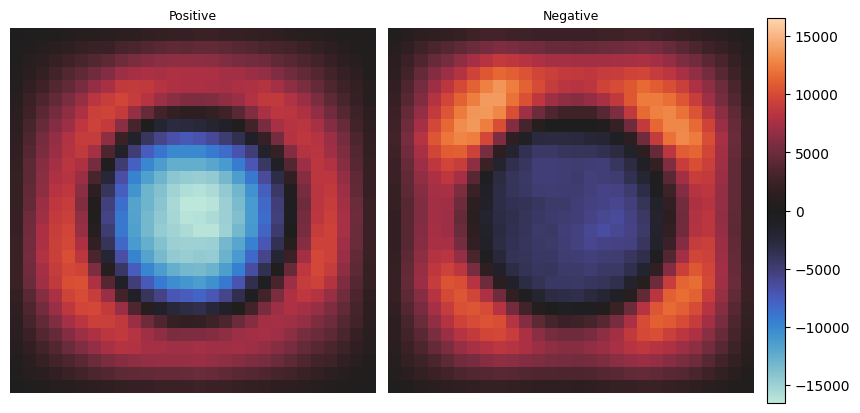

In [10]:
os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

target_class = 0

global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 21:08:02,882 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 21:08:02,885 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 21:08:02,909 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1ae4cc3ef0>
Saved to saved_heatmaps/color_encoding/blood_color_encoding_gh_c0.svg


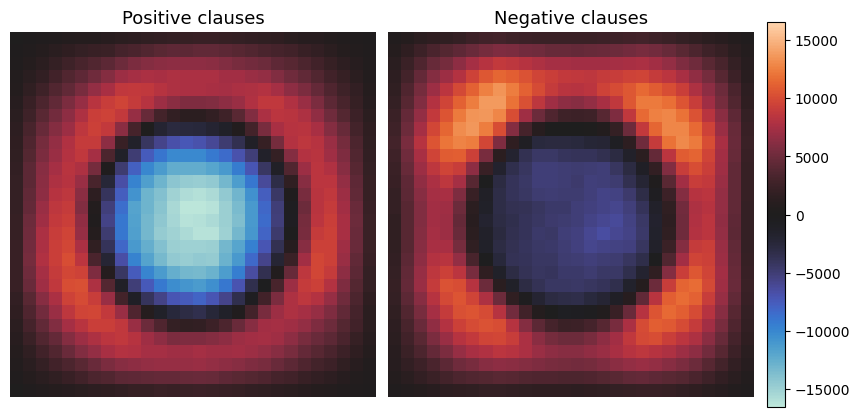

pos shape: (28, 28), min: -16543.82, max: 10258.92
neg shape: (28, 28), min: -6557.34, max: 13793.58
saved_heatmaps/color_encoding/blood_color_encoding_gh_c0.svg


In [10]:
target_class = 0
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)

# Global Heatmap 1

Averaging over 616 correctly predicted samples of class 1


  processed 100/616


  processed 200/616


  processed 300/616


  processed 400/616


  processed 500/616


  processed 600/616


2026-04-09 12:37:18,764 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x726cc40e4e30>


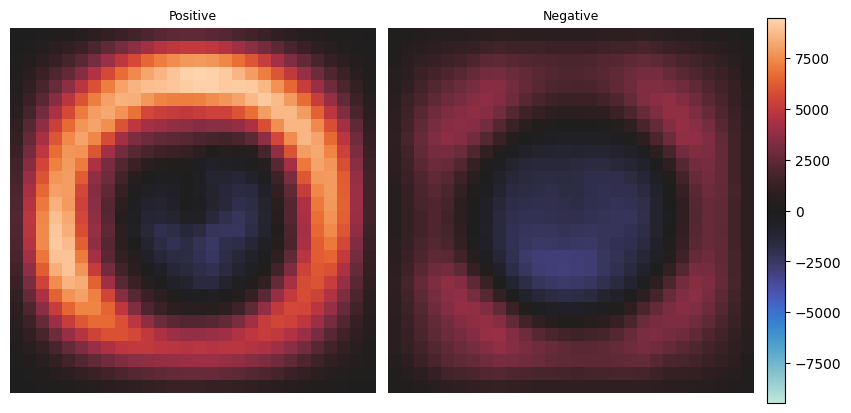

In [12]:
os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

target_class = 1

global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 21:08:03,385 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1932af2b10>
Saved to saved_heatmaps/color_encoding/blood_color_encoding_gh_c1.svg


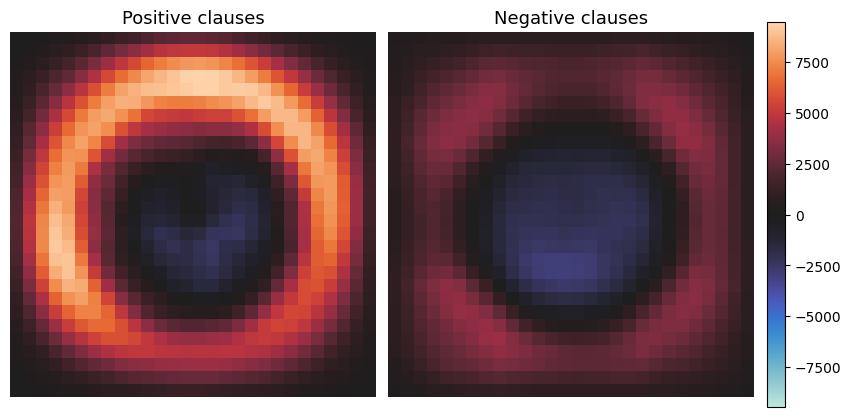

pos shape: (28, 28), min: -2488.77, max: 9476.93
neg shape: (28, 28), min: -2989.42, max: 3973.35
saved_heatmaps/color_encoding/blood_color_encoding_gh_c1.svg


In [11]:
target_class = 1
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)

# Global Heatmap 2

Averaging over 293 correctly predicted samples of class 2


  processed 100/293


  processed 200/293


2026-04-09 16:02:13,434 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x726c854f6240>


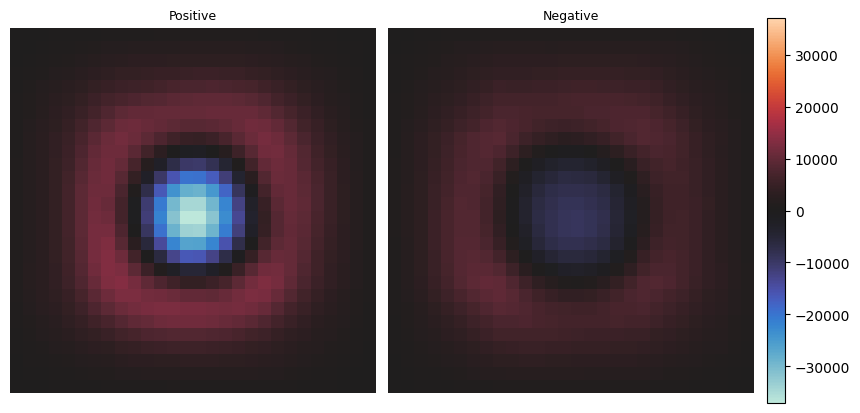

In [14]:
os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

target_class = 2

global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 21:08:05,381 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1932bcde50>


Saved to saved_heatmaps/color_encoding/blood_color_encoding_gh_c2.svg


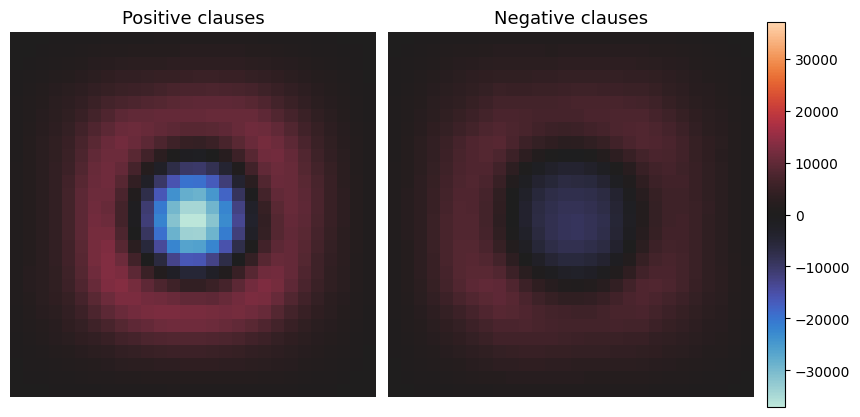

pos shape: (28, 28), min: -37032.73, max: 13389.40
neg shape: (28, 28), min: -9177.90, max: 9945.04
saved_heatmaps/color_encoding/blood_color_encoding_gh_c2.svg


In [12]:
target_class = 2
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)

# Global Heatmap 3

Averaging over 477 correctly predicted samples of class 3


  processed 100/477


  processed 200/477


  processed 300/477


  processed 400/477


2026-04-09 21:56:26,396 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x726c85202840>


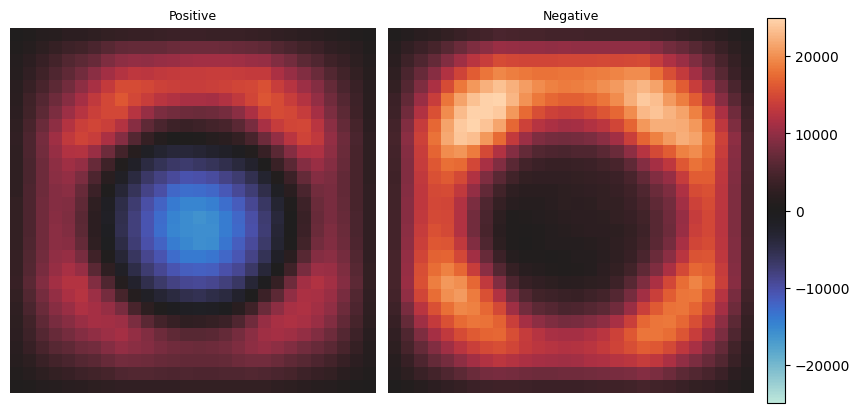

In [16]:
os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

target_class = 3

global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 21:08:13,225 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b19309aa780>


Saved to saved_heatmaps/color_encoding/blood_color_encoding_gh_c3.svg


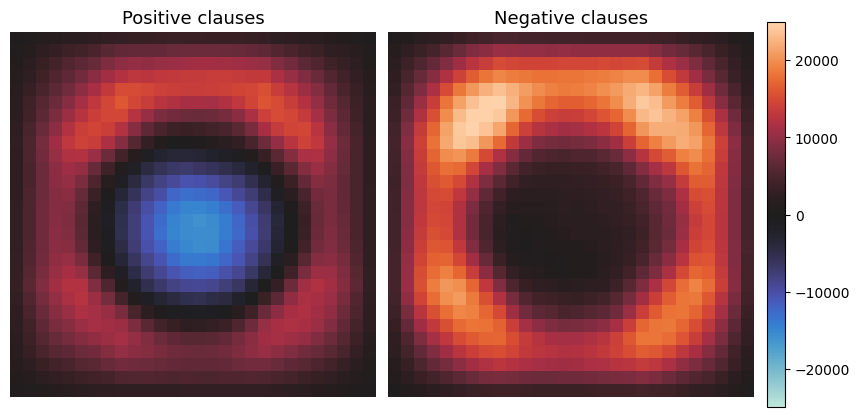

pos shape: (28, 28), min: -15964.12, max: 15983.01
neg shape: (28, 28), min: 306.82, max: 24918.80
saved_heatmaps/color_encoding/blood_color_encoding_gh_c3.svg


In [13]:
target_class = 3
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)

# Global Heatmap 4

Averaging over 234 correctly predicted samples of class 4


  processed 100/234


  processed 200/234


2026-04-10 00:08:22,737 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x726c851098b0>


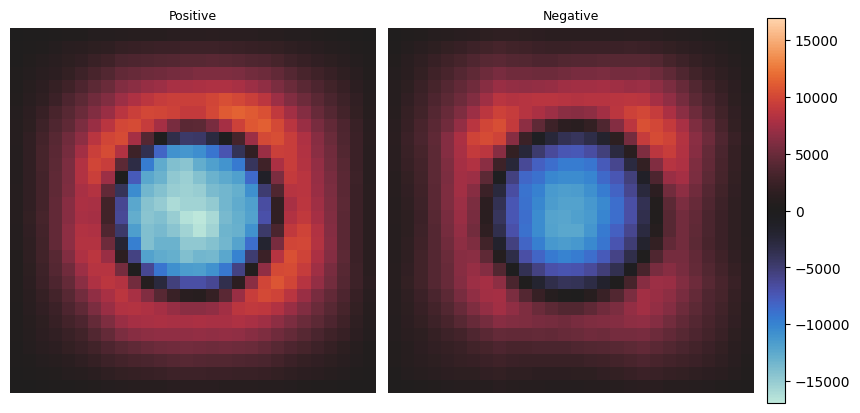

In [18]:
os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

target_class = 4

global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 21:08:16,206 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b19308b8170>


Saved to saved_heatmaps/color_encoding/blood_color_encoding_gh_c4.svg


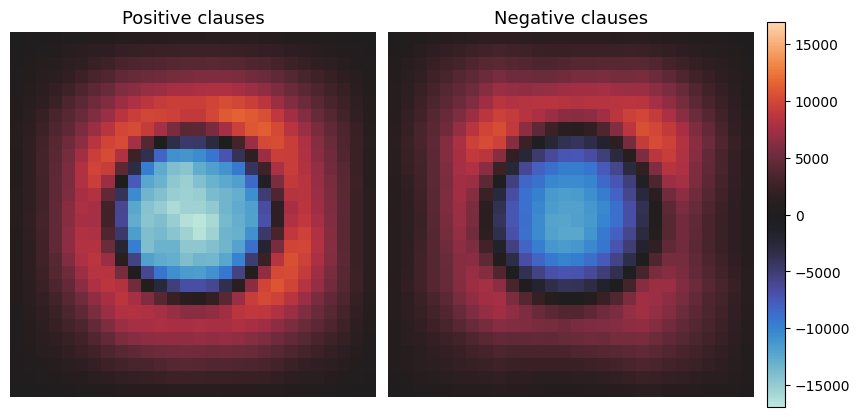

pos shape: (28, 28), min: -16944.65, max: 11386.36
neg shape: (28, 28), min: -12317.68, max: 10499.59
saved_heatmaps/color_encoding/blood_color_encoding_gh_c4.svg


In [14]:
target_class = 4
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)

# Global Heatmap 5

Averaging over 253 correctly predicted samples of class 5


  processed 100/253


  processed 200/253


2026-04-10 03:25:45,993 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x726c8554cdd0>


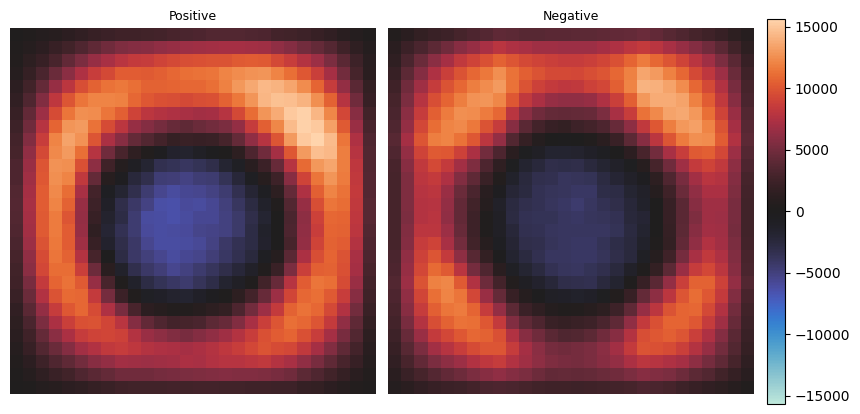

In [20]:
os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

target_class = 5

global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 21:08:19,614 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1930773ef0>


Saved to saved_heatmaps/color_encoding/blood_color_encoding_gh_c5.svg


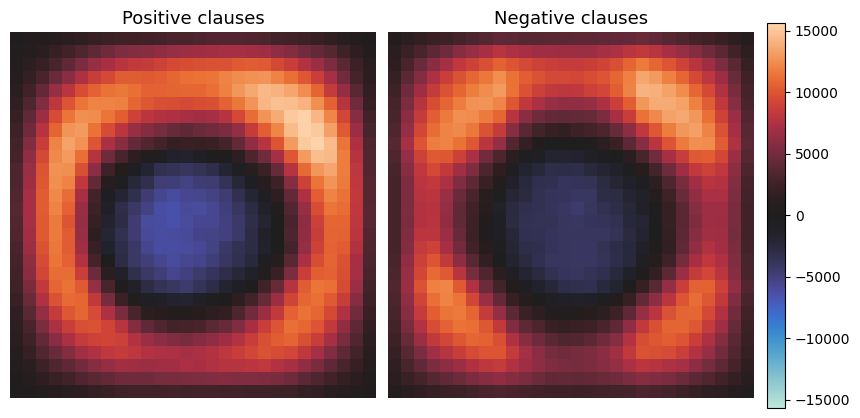

pos shape: (28, 28), min: -6454.19, max: 15655.23
neg shape: (28, 28), min: -4452.46, max: 14174.60
saved_heatmaps/color_encoding/blood_color_encoding_gh_c5.svg


In [15]:
target_class = 5
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)

Averaging over 644 correctly predicted samples of class 6


  processed 100/644


  processed 200/644


  processed 300/644


  processed 400/644


  processed 500/644


  processed 600/644


2026-04-10 09:32:07,503 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x726c857b8b00>


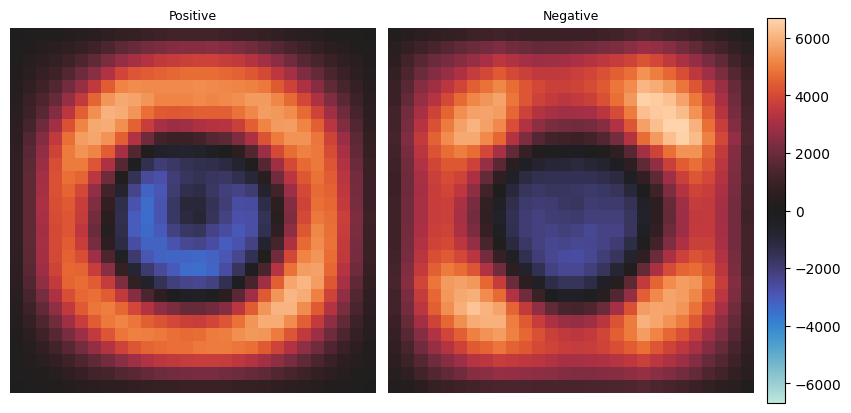

In [22]:
os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

target_class = 6

global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 21:08:23,623 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b19307cac90>
Saved to saved_heatmaps/color_encoding/blood_color_encoding_gh_c6.svg


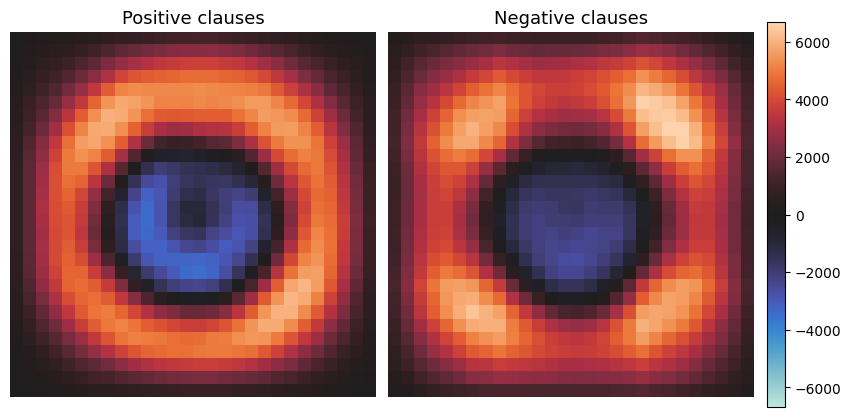

pos shape: (28, 28), min: -3475.32, max: 6093.42
neg shape: (28, 28), min: -2650.45, max: 6682.47
saved_heatmaps/color_encoding/blood_color_encoding_gh_c6.svg


In [16]:
target_class = 6
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)

Averaging over 469 correctly predicted samples of class 7


  processed 100/469


  processed 200/469


  processed 300/469


  processed 400/469


2026-04-10 20:27:21,920 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x726c84e774a0>


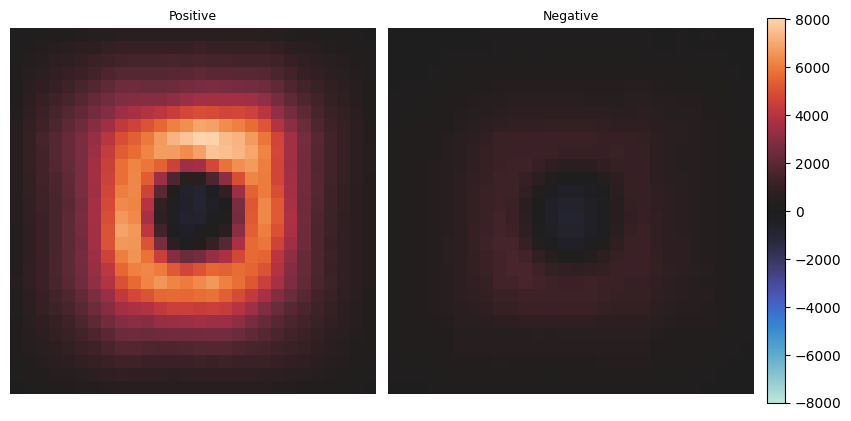

In [24]:
os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

target_class = 7

global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 21:08:27,173 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1930552540>


Saved to saved_heatmaps/color_encoding/blood_color_encoding_gh_c7.svg


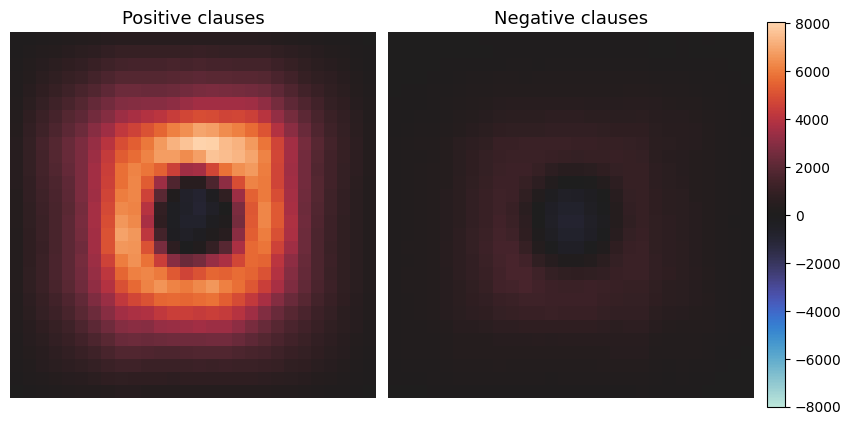

pos shape: (28, 28), min: -955.41, max: 8033.28
neg shape: (28, 28), min: -933.59, max: 1568.80
saved_heatmaps/color_encoding/blood_color_encoding_gh_c7.svg


In [17]:
target_class = 7
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)